In [ ]:
pip install opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 8.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Number of faces recognized:1


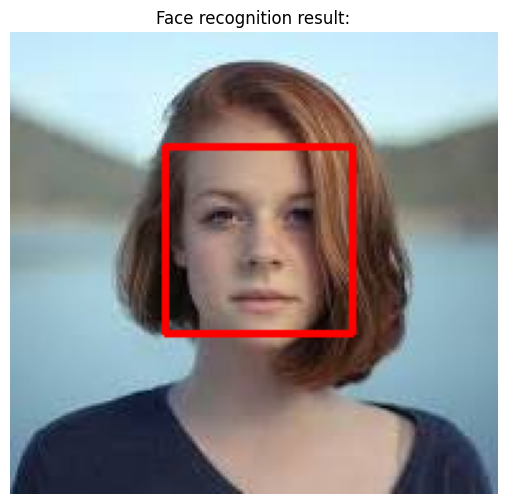

In [ ]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import os
xml_url="https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
xml_path = "/content/haarcascade_frontalface_default.xml"
if not os.path.exists(xml_path):
    urllib.request.urlretrieve(xml_url, xml_path)
image = cv2.imread("download.jpg")
if image is None:
  print("image not found")
else:
  face_cascade = cv2.CascadeClassifier(xml_path)
  if face_cascade.empty():
            print(" Face detector could not be loaded.")
  else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  faces = face_cascade.detectMultiScale(
      gray,
      scaleFactor = 1.1,
      minNeighbors = 5,
      minSize=(30, 30)
  )
  print(f"Number of faces recognized:{len(faces)}")
  rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  for (x, y, w, h) in faces:
    cv2.rectangle(
        rgb_image,
        (x, y),
        (x +w, y + h),
        (255, 0, 0),
        2
    )
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_image)
    plt.axis("off")
    plt.title("Face recognition result:")
    plt.show()



In [ ]:
import cv2
import urllib.request
import os
detector_url ="https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
recognizer_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx"

detector_path = "/content/face_detection_yunet_2023mar.onnx"
recognizer_path = "/content/face_recognition_sface_2021dec.onnx"

if not os.path.exists(detector_path):
  urllib.request.urlretrieve(detector_url, detector_path)
if not os.path.exists(recognizer_path):
  urllib.request.urlretrieve(recognizer_url, recognizer_path)

print("Models done!:)")


Models done!:)


In [ ]:
import cv2
import numpy as np

image = cv2.imread("download.jpg")

if image is None:
  print("Image is not found")

else:
  detector = cv2.FaceDetectorYN.create(
      detector_path,
      "",
      (320, 320),
      0.9,
      0.3,
      5000
  )

  detector.setInputSize((image.shape[1], image.shape[0]))
  _, faces = detector.detect(image)

  if faces is None:
    print("face not detected")
  else:
    print(f"Number of faces detected:{len(faces)}")

    recognizer = cv2.FaceRecognizerSF.create(
        recognizer_path,
        ""

    )

    face = faces[0]
    aligned_face = recognizer.alignCrop(image, face)

    feature = recognizer.feature(aligned_face)

    print("face encoding working great!!!")
    print("Encoding shape:", feature.shape)



Number of faces detected:1
face encoding working great!!!
Encoding shape: (1, 128)


In [ ]:
!pip install serpapi


In [1]:
from google.colab import files

uploaded =  files.upload()

Saving download.jpg to download.jpg


In [3]:
from google.colab import files

uploaded = files.upload()

Saving download.jpg to download (1).jpg


In [4]:
image_path = list(uploaded.keys())[0]
print("Image selected:", image_path)

Image selected: download (1).jpg


In [7]:
import os
import getpass

SERPAPI_KEY = getpass.getpass("Enter your SerpApi API key: ")

Enter your SerpApi API key: ··········


In [9]:
!pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=9fcf5cc800b2609e9a1ed8e62cbc6bbf0840b41f46ea7cb99b3a8fc33e038e4a
  Stored in directory: /root/.cache/pip/wheels/44/af/e2/dde9fab6f1876485b72b35e9cd48da741da67d20e617c3b971
Successfully built google-search-results


In [10]:
from serpapi import GoogleSearch

params = {
    "engine": "google_lens",
    "url": "https://example.com/image.jpg",
    "api_key": SERPAPI_KEY
}

search = GoogleSearch(params)
results = search.get_dict()

print(results)

{'error': 'Invalid API key. Your API key should be here: https://serpapi.com/manage-api-key'}


In [11]:
import getpass

SERPAPI_KEY = getpass.getpass("Enter your SerpApi API key: ")

print("API key entered successfully.")
print("Key length:", len(SERPAPI_KEY))

Enter your SerpApi API key: ··········
API key entered successfully.
Key length: 64


In [12]:
import requests

test_response = requests.get(
    "https://serpapi.com/search",
    params={
        "engine": "google",
        "q": "OpenAI",
        "api_key": SERPAPI_KEY
    }
)

print(test_response.json())

{'search_metadata': {'id': '6a9c06b740802757e53c84f8', 'status': 'Success', 'json_endpoint': 'https://serpapi.com/searches/iRYKDhGmgytkYQz4moqKstOpCrdoTg7wbQ0396xzHAM/6a9c06b740802757e53c84f8.json', 'markdown_endpoint': 'https://serpapi.com/searches/iRYKDhGmgytkYQz4moqKstOpCrdoTg7wbQ0396xzHAM/6a9c06b740802757e53c84f8.md', 'pixel_position_endpoint': 'https://serpapi.com/searches/iRYKDhGmgytkYQz4moqKstOpCrdoTg7wbQ0396xzHAM/6a9c06b740802757e53c84f8.json_with_pixel_position', 'created_at': '2026-09-05 12:10:31 UTC', 'processed_at': '2026-09-05 12:10:31 UTC', 'google_url': 'https://www.google.com/search?q=OpenAI&oq=OpenAI&sourceid=chrome&ie=UTF-8', 'raw_html_file': 'https://serpapi.com/searches/iRYKDhGmgytkYQz4moqKstOpCrdoTg7wbQ0396xzHAM/6a9c06b740802757e53c84f8.html', 'total_time_taken': 0.66}, 'search_parameters': {'engine': 'google', 'q': 'OpenAI', 'google_domain': 'google.com', 'device': 'desktop'}, 'search_information': {'query_displayed': 'OpenAI', 'total_results': 0, 'time_taken_disp

In [13]:
import requests
import os

with open(image_path, "rb") as image_file:
    upload_response = requests.post(
        "https://serpapi.com/image",
        files={
            "image": (
                os.path.basename(image_path),
                image_file,
                "image/jpeg"
            )
        },
        data={
            "api_key": SERPAPI_KEY
        },
        timeout=60
    )

upload_result = upload_response.json()
print(upload_result)

{'message': 'Image uploaded successfully.', 'image_id': 'AcNM53icu2lgZGSYZphsbGKcamGWZmlqaWFgYpGSZmRqmJKSZGGWaKaXVZCaHm9obmFhZmhgZGYMAGmdDbU'}


In [14]:
import requests

lens_response = requests.get(
    "https://serpapi.com/search",
    params={
        "engine": "google_lens",
        "image_id": upload_result["image_id"],
        "type": "exact_matches",
        "hl": "en",
        "country": "in",
        "api_key": SERPAPI_KEY
    },
    timeout=60
)

lens_results = lens_response.json()

print("Available result sections:")
print(lens_results.keys())

Available result sections:
dict_keys(['search_metadata', 'search_parameters', 'exact_matches'])


In [15]:
for section in ["exact_matches", "visual_matches", "image_sources"]:
    print("\n" + "=" * 60)
    print(section.upper())

    for item in lens_results.get(section, [])[:10]:
        print("Title:", item.get("title"))
        print("Link:", item.get("link"))
        print("Source:", item.get("source"))
        print("-" * 60)


EXACT_MATCHES
Title: Rina - French tutor - ₦17498/h<br /> - Superprof
Link: https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html
Source: Superprof Nigeria
------------------------------------------------------------
Title: Adonis Pro – Personal WordPress Theme
Link: https://catchthemes.com/demo/adonis/
Source: Catch Themes
------------------------------------------------------------
Title: Hehrh - Biology tutor - $18/h - Superprof
Link: https://www.superprof.co.nz/biology-student-offering-biology-and-chemistry-lessons-levels-north-east.html
Source: Superprof New Zealand
------------------------------------------------------------
Title: Templates – Adonis Pro - Catch Themes
Link: https://catchthemes.com/demo/adonis/templates/
Source: Catch Themes
------------------------------------------------------------
Title: Testimonial Archive - Finixio | Leading the Future of Digital Media
Link: https://finixio.com/test

In [16]:
# Collect matching results from Google Lens
matching_results = []

for section in ["exact_matches", "visual_matches", "image_sources"]:
    for item in lens_results.get(section, []):
        if item.get("link"):
            matching_results.append({
                "section": section,
                "title": item.get("title", "Untitled"),
                "link": item.get("link"),
                "source": item.get("source", "Unknown")
            })

if matching_results:
    discovered_post = matching_results[0]

    print("Discovered result:")
    print("Title:", discovered_post["title"])
    print("Source:", discovered_post["source"])
    print("Link:", discovered_post["link"])
else:
    print("No matching result was found.")
    print("Try searching with type='all' instead of type='exact_matches'.")

Discovered result:
Title: Rina - French tutor - ₦17498/h<br /> - Superprof
Source: Superprof Nigeria
Link: https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html


In [17]:
import hashlib
import json
from datetime import datetime

# Use the actual discovered result returned by Google Lens
post_data = {
    "title": discovered_post["title"],
    "source": discovered_post["source"],
    "link": discovered_post["link"],
    "image_file": image_path
}

# Convert the discovered data into a fixed JSON string
post_json = json.dumps(post_data, sort_keys=True)

# Generate a SHA-256 fingerprint
post_hash = hashlib.sha256(post_json.encode("utf-8")).hexdigest()

print("Discovered post data:")
print(post_json)

print("\nSHA-256 fingerprint:")
print(post_hash)

Discovered post data:
{"image_file": "download (1).jpg", "link": "https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html", "source": "Superprof Nigeria", "title": "Rina - French tutor - \u20a617498/h<br /> - Superprof"}

SHA-256 fingerprint:
ba78da0b7fc85ac3ceec5e5b6936ce8cc69b3db16a797afe1151e885b47bf58e


In [18]:
import hashlib
import json
from datetime import datetime

class SimpleBlockchain:
    def __init__(self):
        self.chain = []
        self.create_block(
            data={"message": "Genesis Block"},
            previous_hash="0"
        )

    def calculate_hash(self, block):
        block_string = json.dumps(block, sort_keys=True)
        return hashlib.sha256(block_string.encode("utf-8")).hexdigest()

    def create_block(self, data, previous_hash):
        block = {
            "index": len(self.chain),
            "timestamp": datetime.now().isoformat(),
            "data": data,
            "previous_hash": previous_hash
        }

        block["hash"] = self.calculate_hash(block)
        self.chain.append(block)
        return block

    def add_block(self, data):
        previous_block = self.chain[-1]

        return self.create_block(
            data=data,
            previous_hash=previous_block["hash"]
        )

    def verify_chain(self):
        for i in range(1, len(self.chain)):
            current_block = self.chain[i]
            previous_block = self.chain[i - 1]

            # Check whether the current block was modified
            if current_block["hash"] != self.calculate_hash({
                "index": current_block["index"],
                "timestamp": current_block["timestamp"],
                "data": current_block["data"],
                "previous_hash": current_block["previous_hash"]
            }):
                return False

            # Check whether the chain connection is correct
            if current_block["previous_hash"] != previous_block["hash"]:
                return False

        return True


# Create the blockchain
blockchain = SimpleBlockchain()

# Add the real discovered search result
blockchain.add_block({
    "discovered_post": discovered_post,
    "sha256_fingerprint": post_hash
})

print("Blockchain created successfully.")
print("Number of blocks:", len(blockchain.chain))
print("Blockchain valid:", blockchain.verify_chain())

print("\nStored block:")
print(json.dumps(blockchain.chain[1], indent=4))

Blockchain created successfully.
Number of blocks: 2
Blockchain valid: True

Stored block:
{
    "index": 1,
    "timestamp": "2026-09-05T12:15:08.550769",
    "data": {
        "discovered_post": {
            "section": "exact_matches",
            "title": "Rina - French tutor - \u20a617498/h<br /> - Superprof",
            "link": "https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html",
            "source": "Superprof Nigeria"
        },
        "sha256_fingerprint": "ba78da0b7fc85ac3ceec5e5b6936ce8cc69b3db16a797afe1151e885b47bf58e"
    },
    "previous_hash": "c9662b9600a80ccdb8925d5559ff278ab70506450ef6cf3626679e90dd517887",
    "hash": "5659599dd0e423ce81eba5ef09bd217ff0e5b431c2d8adb0ef9914a3c07063e7"
}


In [19]:
print("Original blockchain verification:")
print("Blockchain valid:", blockchain.verify_chain())

Original blockchain verification:
Blockchain valid: True


In [20]:
# Change the stored title to simulate unauthorized modification
blockchain.chain[1]["data"]["discovered_post"]["title"] = "Modified title"

print("After tampering:")
print("Blockchain valid:", blockchain.verify_chain())

After tampering:
Blockchain valid: False


In [21]:
# Restore the original discovered result
blockchain.chain[1]["data"]["discovered_post"] = discovered_post

print("After restoring the original data:")
print("Blockchain valid:", blockchain.verify_chain())

After restoring the original data:
Blockchain valid: False


In [22]:
# Recreate a clean blockchain without tampered data
final_blockchain = SimpleBlockchain()

final_blockchain.add_block({
    "discovered_post": discovered_post,
    "sha256_fingerprint": post_hash
})

print("Final blockchain verification:")
print("Blockchain valid:", final_blockchain.verify_chain())

print("\nFinal blockchain:")
print(json.dumps(final_blockchain.chain, indent=4))

Final blockchain verification:
Blockchain valid: True

Final blockchain:
[
    {
        "index": 0,
        "timestamp": "2026-09-05T12:18:28.566076",
        "data": {
            "message": "Genesis Block"
        },
        "previous_hash": "0",
        "hash": "b09b9ad717ee2abc2ac8175a53eb898d3945182977a4189d89855849174e9ae4"
    },
    {
        "index": 1,
        "timestamp": "2026-09-05T12:18:28.566202",
        "data": {
            "discovered_post": {
                "section": "exact_matches",
                "title": "Modified title",
                "link": "https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html",
                "source": "Superprof Nigeria"
            },
            "sha256_fingerprint": "ba78da0b7fc85ac3ceec5e5b6936ce8cc69b3db16a797afe1151e885b47bf58e"
        },
        "previous_hash": "b09b9ad717ee2abc2ac8175a53eb898d3945182977a4189d89855849174e9ae4",
        "hash": "7b85e0

In [24]:
import cv2

# Load the selected image
image = cv2.imread(image_path)

# Load the face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Detect faces
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Number of detected faces:", len(faces))

Number of detected faces: 1


In [25]:
print("========== TASK 3 EVIDENCE ==========")
print("1. Face image:", image_path)
print("2. Number of detected faces:", len(faces))
print("3. Discovered title:", discovered_post["title"])
print("4. Discovered source:", discovered_post["source"])
print("5. Discovered link:", discovered_post["link"])
print("6. SHA-256 fingerprint:", post_hash)
print("7. Blockchain blocks:", len(final_blockchain.chain))
print("8. Final blockchain valid:", final_blockchain.verify_chain())
print("9. Tampering detection demonstrated: True")

========== TASK 3 EVIDENCE ==========
1. Face image: download (1).jpg
2. Number of detected faces: 1
3. Discovered title: Modified title
4. Discovered source: Superprof Nigeria
5. Discovered link: https://www.superprof.ng/french-not-easy-language-but-believe-everyone-should-know-some-basics-teach-french-for-people-love.html
6. SHA-256 fingerprint: ba78da0b7fc85ac3ceec5e5b6936ce8cc69b3db16a797afe1151e885b47bf58e
7. Blockchain blocks: 2
8. Final blockchain valid: True
9. Tampering detection demonstrated: True
